In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_cleaned_v2.csv')

In [4]:
df.shape

(3790, 23)

# Numerical columns

# price column

<Axes: xlabel='price_in_cr', ylabel='Count'>

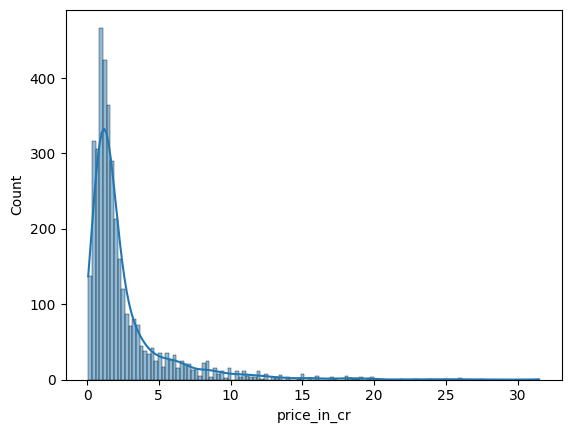

In [5]:
sns.histplot(df['price_in_cr'], kde = True)

<Axes: xlabel='price_in_cr'>

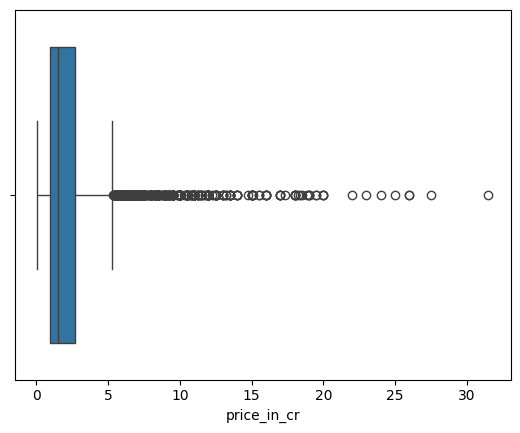

In [6]:
sns.boxplot(x = df['price_in_cr'])

In [7]:
# IQR range 

Q1 = df['price_in_cr'].quantile(0.25)
Q3 = df['price_in_cr'].quantile(0.75)

IQR_range = Q3 - Q1

lower_bound = Q1 - 1.5*IQR_range
upper_bound = Q3 + 1.5 * IQR_range

outlier_df = df[(df['price_in_cr'] < lower_bound) | (df['price_in_cr'] > upper_bound)]

In [8]:
outlier_df['price_in_cr'].describe()

count    432.000000
mean       9.196157
std        4.061291
min        5.350000
25%        6.400000
50%        8.000000
75%       10.607500
max       31.500000
Name: price_in_cr, dtype: float64

In [9]:
outlier_df.sort_values(by = 'price_in_cr').to_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\outlier_price.csv', index=False)

- based on the csv file. Many properties in outlier_price.csv seem to be genuine outliers

### price_per_sqft

<Axes: xlabel='price_per_sqft', ylabel='Count'>

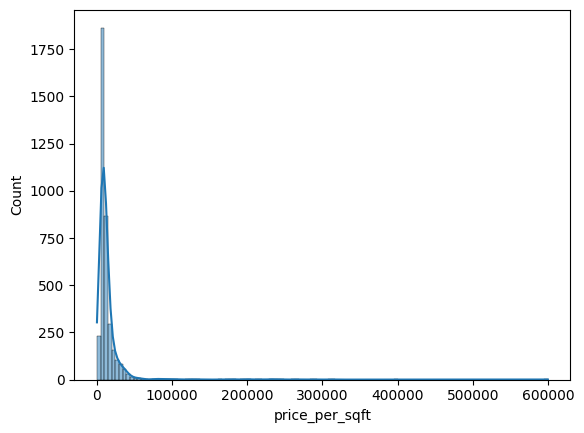

In [10]:
sns.histplot(df['price_per_sqft'], kde = True)

<Axes: xlabel='price_per_sqft'>

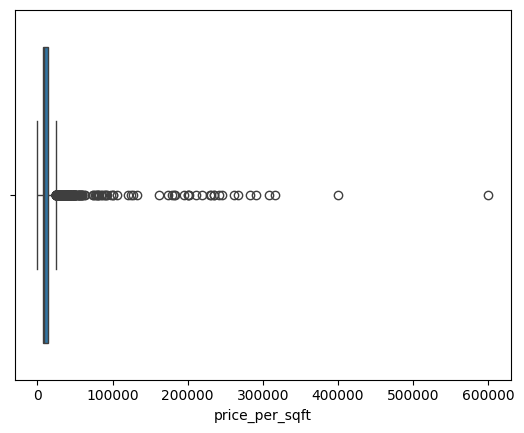

In [11]:
sns.boxplot(x = df['price_per_sqft'])

In [12]:
# IQR range 

Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)

IQR_range = Q3 - Q1

lower_bound = Q1 - 1.5*IQR_range
upper_bound = Q3 + 1.5 * IQR_range

outlier_price_per_sqft_df = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

In [13]:
outlier_price_per_sqft_df['price_per_sqft'].describe()

count       367.000000
mean      52115.435967
std       60746.225927
min       24202.000000
25%       27778.000000
50%       33333.000000
75%       41790.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

In [14]:
outlier_price_per_sqft_df.sort_values(by='price_per_sqft', ascending=False)

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
3605,house,emaar the palm springs,sector 54,24.00,600000.0,400.00,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,old,NaN,400.0,NaN,1,1,1,0,0,0,94.0
3110,house,dlf city plots phase 2,sector 25,10.00,400000.0,250.00,Plot area 250(23.23 sq.m.),12,12,3+,4.0,North,relatively new,NaN,250.0,NaN,1,1,0,0,0,0,79.0
802,house,independent,sector 12,6.00,315789.0,190.00,Plot area 190(17.65 sq.m.)Carpet area: 1600 sq...,9,6,2,2.0,North-East,old,NaN,NaN,1600.0,0,0,0,0,0,1,NaN
1664,house,ansal,sector 43,1.85,308333.0,60.00,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,relatively new,NaN,60.0,NaN,0,0,0,0,0,1,36.0
1293,house,uppal southend,sector 49,6.75,290948.0,232.00,Plot area 232(21.55 sq.m.),12,12,3+,NaN,West,relatively old,NaN,232.0,NaN,1,1,1,0,1,0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1730,flat,central park resort belgravia residences,sector 48,6.25,24300.0,2572.02,Carpet area: 2880 (267.56 sq.m.),3,5,3+,5.0,south-east,relatively old,NaN,NaN,2880.0,1,0,0,0,0,0,24.0
118,house,international city by sobha phase 1,sector 109,5.90,24280.0,2429.98,Plot area 270(225.75 sq.m.),4,5,2,2.0,East,relatively new,NaN,2430.0,NaN,1,0,0,0,0,0,86.0
3430,house,independent,sector 17,3.93,24214.0,1623.03,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,relatively new,NaN,1622.0,NaN,1,1,1,1,0,1,57.0
1490,flat,m3m golfestate,sector 65,5.30,24211.0,2189.09,Super Built up area 2850(264.77 sq.m.)Carpet a...,3,3,3,38.0,north-east,relatively old,2850.0,NaN,2189.0,1,0,0,0,0,2,24.0


- some of the values in area column are in sq yard instead of sqft and therefore price_per_sqft is exceptionally high 

In [15]:
outlier_price_per_sqft_df

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
9,house,independent,sector 25,4.31,31926.0,1350.00,Plot area 150(125.42 sq.m.),5,4,3,3.0,North,old,NaN,1350.0,NaN,0,0,0,0,0,1,21.0
35,house,independent,sector 57,4.75,28787.0,1650.05,Plot area 1600(148.64 sq.m.)Built Up area: 170...,3,3,3,2.0,North-West,relatively old,NaN,1700.0,1650.0,0,0,0,1,0,0,73.0
59,house,independent,sector 25,9.50,33404.0,2843.97,Plot area 316(264.22 sq.m.),9,9,3+,3.0,North-West,old,NaN,2844.0,NaN,0,0,0,0,1,1,53.0
73,flat,housing board colony,sector 51,0.30,41666.0,72.00,Carpet area: 72 (6.69 sq.m.),1,1,0,0.0,NaN,relatively old,NaN,NaN,72.0,0,1,0,0,0,1,7.0
87,house,independent,sector 3,0.61,100000.0,61.00,Plot area 61(5.67 sq.m.),2,2,2,2.0,South-East,relatively old,NaN,61.0,NaN,0,0,0,0,1,1,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3699,house,independent,sector 41,7.00,28283.0,2474.98,Plot area 275(229.94 sq.m.),7,7,3+,3.0,South-West,relatively old,NaN,2475.0,NaN,1,1,1,1,0,2,119.0
3700,flat,dlf the belaire,sector 54,10.00,24557.0,4072.16,Super Built up area 4072(378.3 sq.m.)Built Up ...,4,5,3+,17.0,north,relatively old,4072.0,3000.0,2800.0,1,0,0,0,0,2,148.0
3735,house,unitech escape,sector 50,12.00,37037.0,3240.00,Carpet area: 360 (301.01 sq.m.),5,6,3+,3.0,East,undefined,NaN,NaN,360.0,0,0,0,0,0,1,62.0
3780,house,independent,sector 50,11.58,35741.0,3239.98,Plot area 360(301.01 sq.m.),5,5,3,2.0,NaN,relatively old,NaN,3240.0,NaN,1,0,0,0,0,1,10.0


In [16]:
# modify areas which are less than 1000 (means those areas are in sqyard)
outlier_price_per_sqft_df['area'] = outlier_price_per_sqft_df['area'].apply(lambda x: x*9 if x < 1000 else x)


In [17]:
# calculate price per sqft again
outlier_price_per_sqft_df['price_per_sqft'] = ((outlier_price_per_sqft_df['price_in_cr']*10000000)/(outlier_price_per_sqft_df['area'])).round(2)

In [18]:
outlier_price_per_sqft_df['price_in_cr'].describe()

count    367.000000
mean       8.049891
std        5.214262
min        0.300000
25%        4.450000
50%        7.250000
75%       10.825000
max       31.500000
Name: price_in_cr, dtype: float64

In [19]:
df.update(outlier_price_per_sqft_df)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

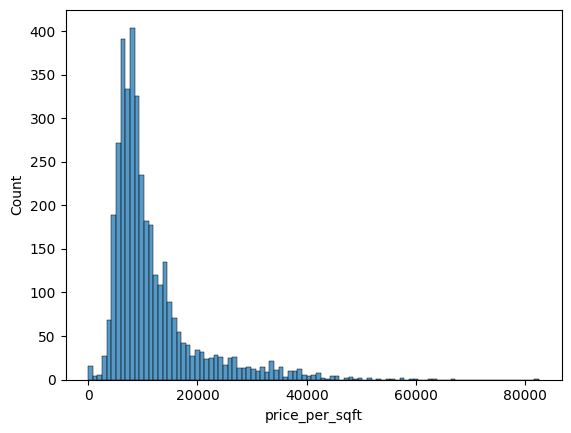

In [20]:
sns.histplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

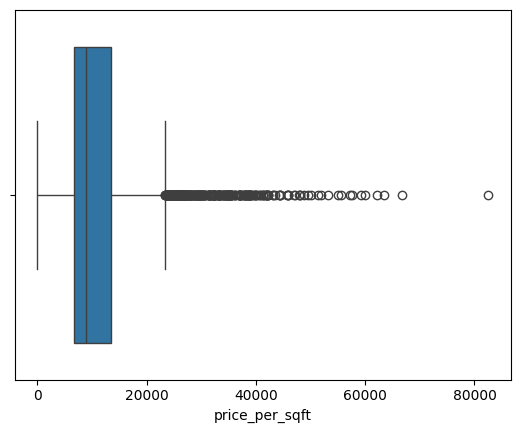

In [22]:
sns.boxplot(x = df['price_per_sqft'])

- after correcting the area column, there is improvement in the distribution

In [26]:
df[df['price_per_sqft'] > 50000].shape

(13, 23)

- since there are only 13 values with more than 50k price per sqft, we will remove them

In [28]:
df = df[df['price_per_sqft'] < 50000]

<Axes: xlabel='price_per_sqft'>

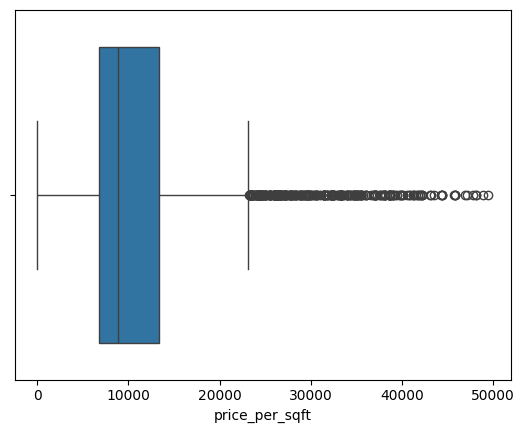

In [30]:
sns.boxplot(x = df['price_per_sqft'])

### Area column

In [34]:
df['area'].describe()

count      3758.000000
mean       2910.981317
std       22864.613666
min         145.010000
25%        1258.237500
50%        1745.015000
75%        2340.012500
max      875000.000000
Name: area, dtype: float64

<Axes: xlabel='area', ylabel='Count'>

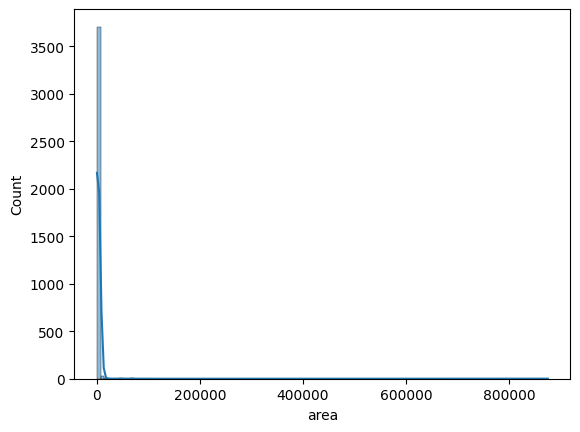

In [35]:
sns.histplot(df['area'], kde = True)

<Axes: xlabel='area'>

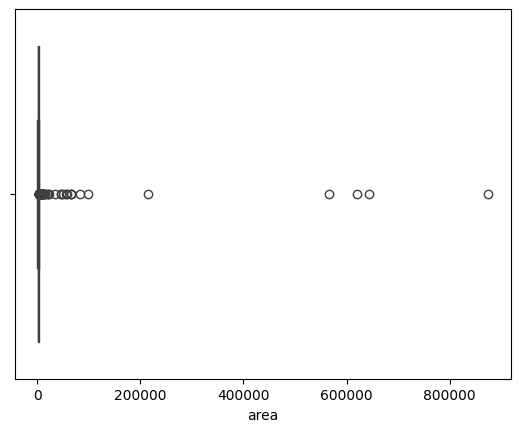

In [36]:
sns.boxplot(x = df['area'])

In [37]:
df.sort_values(by = 'area', ascending=False)

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
2563,flat,hcbs sports ville,sector 47,0.35,4.0,875000.00,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,relatively new,NaN,737147.0,NaN,0,0,0,0,0,2,21.0
2765,flat,signature the roselia,sector 95,0.45,7.0,642857.14,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,south-west,new,NaN,NaN,569243.0,0,0,0,0,0,1,62.0
26,flat,ramsons kshitij,sector 95,0.31,5.0,620000.00,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,north-east,relatively new,NaN,NaN,607936.0,0,1,0,0,1,1,39.0
22,flat,signature global solera 2,sector 107,0.51,9.0,566666.67,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,north,new,NaN,NaN,514396.0,0,0,0,0,0,1,21.0
3677,house,independent,sector 50,5.00,232.0,215517.24,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,new,NaN,2.0,NaN,1,1,1,0,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,house,independent,sector 9,0.22,7407.0,297.02,Carpet area: 33 (27.59 sq.m.),2,2,2,1.0,NaN,undefined,NaN,NaN,33.0,0,0,0,0,0,1,NaN
3743,house,my home,sector 2,0.34,12592.0,270.01,Plot area 270(25.08 sq.m.),2,2,2,3.0,West,relatively old,NaN,270.0,NaN,0,0,0,0,0,1,9.0
1194,flat,ansal api sushant estate,sector 52,0.29,11600.0,250.00,Carpet area: 250 (23.23 sq.m.),1,1,0,0.0,NaN,relatively old,NaN,NaN,250.0,0,0,0,0,0,0,24.0
3421,house,independent,sector 7,0.27,12000.0,225.00,Plot area 225(20.9 sq.m.),2,2,1,2.0,North-East,relatively old,NaN,225.0,NaN,0,0,0,0,0,1,5.0


In [38]:
df[df['area'] > 100000]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
22,flat,signature global solera 2,sector 107,0.51,9.0,566666.67,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,north,new,NaN,NaN,514396.0,0,0,0,0,0,1,21.0
26,flat,ramsons kshitij,sector 95,0.31,5.0,620000.00,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,north-east,relatively new,NaN,NaN,607936.0,0,1,0,0,1,1,39.0
2563,flat,hcbs sports ville,sector 47,0.35,4.0,875000.00,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,relatively new,NaN,737147.0,NaN,0,0,0,0,0,2,21.0
2765,flat,signature the roselia,sector 95,0.45,7.0,642857.14,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,south-west,new,NaN,NaN,569243.0,0,0,0,0,0,1,62.0
3677,house,independent,sector 50,5.00,232.0,215517.24,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,new,NaN,2.0,NaN,1,1,1,0,1,0,NaN


- price and area doesn't logically makes sense. Therefore removing these rows

In [39]:
df= df[df['area']< 100000]

In [40]:
df.shape

(3753, 23)

<Axes: xlabel='area'>

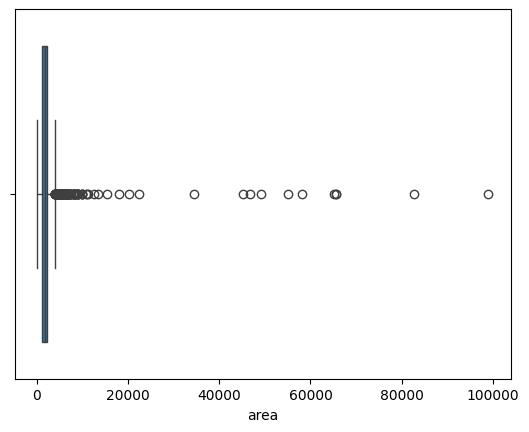

In [41]:
sns.boxplot(x = df['area'])

In [45]:
pd.set_option('display.max_columns', None)

In [52]:
df[df['area'] > 10000]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
126,house,ganpati heights apartment,sector 12,1.25,151.0,82781.46,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,old,NaN,115.0,NaN,0,0,0,0,1,1,4.0
274,house,independent,sector 43,27.50,24366.0,11286.22,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,relatively new,NaN,11286.0,NaN,1,1,1,0,1,0,28.0
981,house,independent,sector 25,7.30,1560.0,46794.87,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,relatively new,NaN,5800.0,5200.00,1,0,0,1,0,0,84.0
1486,house,independent,sector 47,5.50,5093.0,10799.14,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,relatively old,NaN,3500.0,NaN,1,1,1,0,1,1,28.0
1776,house,independent,sector 3,0.85,630.0,13492.06,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,relatively new,NaN,13500.0,NaN,0,0,0,0,1,1,NaN
1934,flat,rof ananda,sector 95,0.21,61.0,34426.23,Carpet area: 34401 (3195.96 sq.m.),1,1,1,13.0,north,relatively new,NaN,NaN,34401.00,0,0,0,0,0,1,49.0
2576,flat,m3m golfestate,sector 65,13.20,12000.0,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,north,relatively old,NaN,NaN,11000.00,1,0,0,0,0,1,48.0
2623,house,independent,sector 57,6.25,2778.0,22498.20,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,new,NaN,2660.0,2500.00,1,0,0,0,0,0,43.0
2916,house,independent,sector 43,5.50,2716.0,20250.37,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,relatively old,NaN,2850.0,2250.00,1,1,1,0,1,0,101.0
3030,flat,godrej air,sector 85,2.50,1379.0,18129.08,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,north-east,under construction,NaN,NaN,18122.00,0,1,1,0,1,0,21.0


In [49]:
# 2161, 3616, 3773, 3346, 1427, 3007, 3016 --> manually found data errors in these rows. Therefore remove these rows

df.drop(index=[2161, 3616, 3773, 3346, 1427, 3007, 3016], inplace =True)

<Axes: xlabel='area', ylabel='Count'>

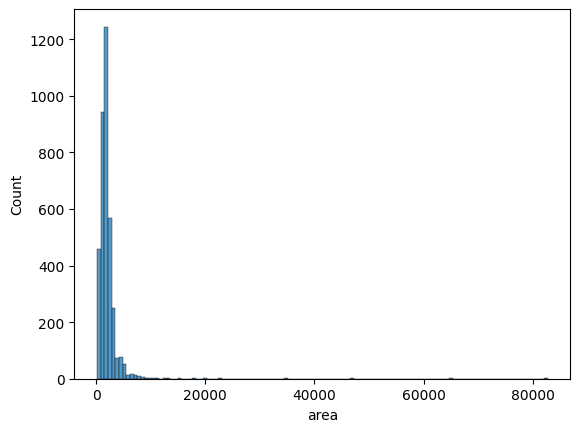

In [50]:
sns.histplot(df['area'])

In [56]:
df[df['area'] > 10000].sort_values(by= 'area', ascending=False)

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
126,house,ganpati heights apartment,sector 12,1.25,151.0,82781.46,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,old,NaN,115.0,NaN,0,0,0,0,1,1,4.0
3116,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.04,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,undefined,NaN,NaN,7250.00,0,0,0,0,0,1,NaN
981,house,independent,sector 25,7.30,1560.0,46794.87,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,relatively new,NaN,5800.0,5200.00,1,0,0,1,0,0,84.0
1934,flat,rof ananda,sector 95,0.21,61.0,34426.23,Carpet area: 34401 (3195.96 sq.m.),1,1,1,13.0,north,relatively new,NaN,NaN,34401.00,0,0,0,0,0,1,49.0
2623,house,independent,sector 57,6.25,2778.0,22498.20,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,new,NaN,2660.0,2500.00,1,0,0,0,0,0,43.0
2916,house,independent,sector 43,5.50,2716.0,20250.37,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,relatively old,NaN,2850.0,2250.00,1,1,1,0,1,0,101.0
3030,flat,godrej air,sector 85,2.50,1379.0,18129.08,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,north-east,under construction,NaN,NaN,18122.00,0,1,1,0,1,0,21.0
3310,house,unitech aspen greens,sector 50,6.95,4490.0,15478.84,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,relatively old,NaN,2160.0,1720.00,1,0,0,0,0,1,132.0
1776,house,independent,sector 3,0.85,630.0,13492.06,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,relatively new,NaN,13500.0,NaN,0,0,0,0,1,1,NaN
3682,flat,godrej icon,sector 88,1.75,1384.0,12644.51,Carpet area: 1175.11,3,3,3+,6.0,NaN,new,NaN,NaN,1175.11,0,0,0,0,0,1,67.0


In [57]:
df.loc[126, 'area'] = 115*9
df.loc[3116, 'area'] = 7250
df.loc[981, 'area'] = 5800
df.loc[2623, 'area'] = 2660
df.loc[2916, 'area'] = 2850
df.loc[3030, 'area'] = 1812
df.loc[3310, 'area'] = 2160
df.loc[3682, 'area'] = 1175



C:\Users\apaks\AppData\Local\Temp\ipykernel_15228\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

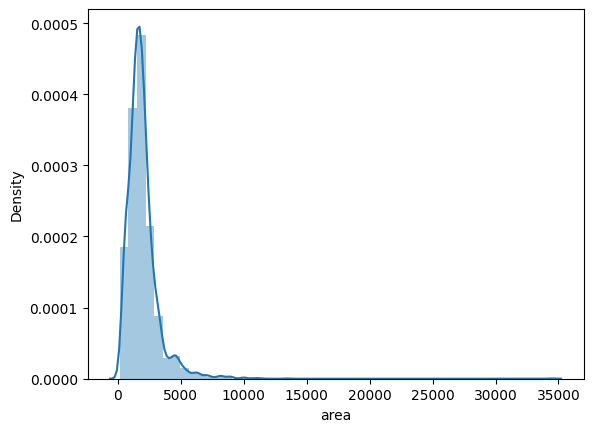

In [59]:
sns.distplot(df['area'])

In [60]:
df[df['area'] > 10000]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
274,house,independent,sector 43,27.50,24366.0,11286.22,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,relatively new,NaN,11286.0,NaN,1,1,1,0,1,0,28.0
1486,house,independent,sector 47,5.50,5093.0,10799.14,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,relatively old,NaN,3500.0,NaN,1,1,1,0,1,1,28.0
1776,house,independent,sector 3,0.85,630.0,13492.06,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,relatively new,NaN,13500.0,NaN,0,0,0,0,1,1,NaN
1934,flat,rof ananda,sector 95,0.21,61.0,34426.23,Carpet area: 34401 (3195.96 sq.m.),1,1,1,13.0,north,relatively new,NaN,NaN,34401.0,0,0,0,0,0,1,49.0
2576,flat,m3m golfestate,sector 65,13.20,12000.0,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,north,relatively old,NaN,NaN,11000.0,1,0,0,0,0,1,48.0


In [61]:
df.drop(index = 1934, inplace = True)

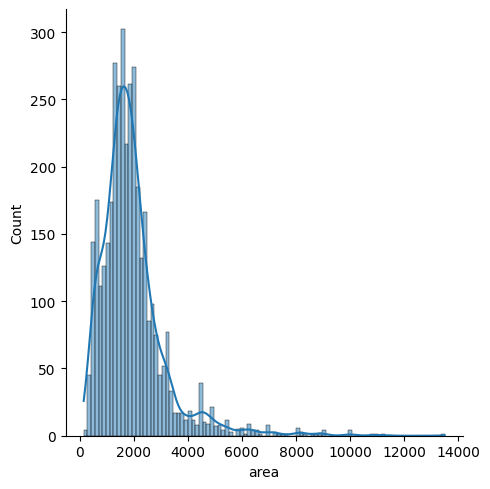

In [64]:
sns.displot(df['area'], kde = True)

<Axes: xlabel='area'>

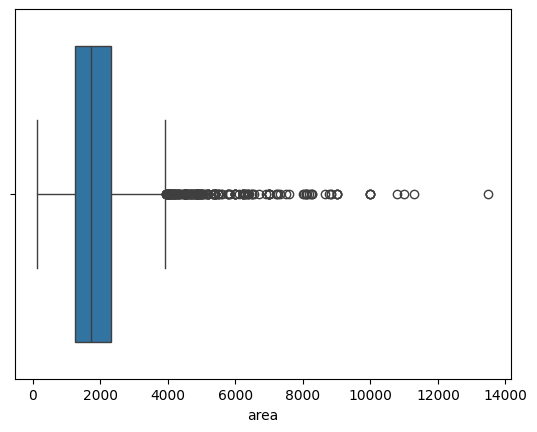

In [65]:
sns.boxplot(x = df['area'])

In [66]:
df['area'].describe()

count     3745.000000
mean      1946.130315
std       1229.065389
min        145.010000
25%       1251.200000
50%       1742.870000
75%       2320.190000
max      13492.060000
Name: area, dtype: float64

### Bedroom

In [68]:
df['bedRoom'].describe()

count    3745.000000
mean        3.306809
std         1.795834
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

<Axes: xlabel='bedRoom'>

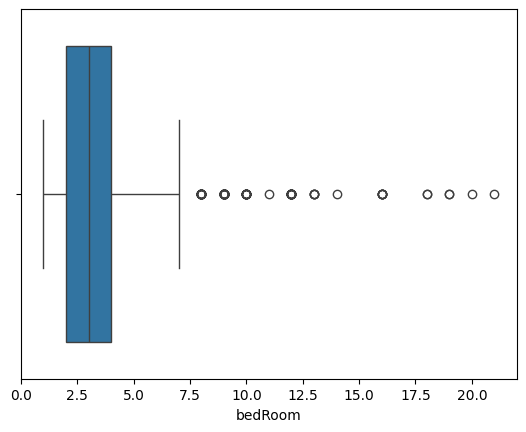

In [69]:
sns.boxplot(x= df['bedRoom'])

- remove the properties with more than 10 bedrooms and cost less than a crore. High possibility of data error

In [86]:
temp_df = df[(df['bedRoom'] > 10) & (df['price_in_cr'] < 5)]
temp_df.index

Index([1362, 2646, 3390], dtype='int64')

In [87]:
df.drop(index = temp_df.index, inplace = True)

<Axes: xlabel='bedRoom'>

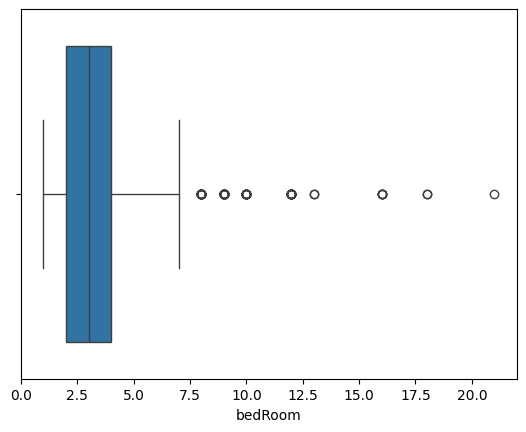

In [88]:
sns.boxplot(x = df['bedRoom'])

In [91]:
df[df['bedRoom'] > 10].sort_values(by= 'bedRoom')

#404, 2923, 1595, 3271, 404 --> these prices and number of bedroom seem data error. Therefore removing them

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
223,house,independent,sector 26,10.50,43210.05,2429.99,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,4.0,North-East,relatively new,NaN,300.0,270.0,1,0,1,0,0,0,47.0
444,house,independent,sector 46,6.50,27461.04,2366.99,Plot area 263(219.9 sq.m.),12,12,3+,4.0,North-West,relatively new,NaN,2367.0,NaN,0,1,1,0,0,0,17.0
705,house,independent,sector 47,6.09,33665.01,1809.00,Plot area 201(168.06 sq.m.)Built Up area: 180 ...,12,11,3+,4.0,West,relatively old,NaN,180.0,150.0,0,0,1,0,0,2,27.0
877,house,independent,sector 56,11.50,42032.01,2736.01,Plot area 304(254.18 sq.m.),12,13,3+,4.0,West,relatively new,NaN,2736.0,NaN,1,1,1,0,0,0,30.0
1118,house,independent,sector 57,6.95,38610.90,1800.01,Plot area 192(160.54 sq.m.),12,12,3+,4.0,East,new,NaN,1728.0,NaN,1,0,0,1,0,0,51.0
968,house,independent,sector 27,8.25,45833.08,1800.01,Plot area 210(175.59 sq.m.)Built Up area: 205 ...,12,12,3+,4.0,East,new,NaN,205.0,200.0,1,0,1,0,0,0,21.0
1293,house,uppal southend,sector 49,6.75,32327.59,2088.00,Plot area 232(21.55 sq.m.),12,12,3+,NaN,West,relatively old,NaN,232.0,NaN,1,1,1,0,1,0,30.0
1225,house,floor wise designer kothi,sector 25,13.00,48147.97,2700.01,Plot area 300(250.84 sq.m.),12,16,3+,4.0,North-East,new,NaN,2700.0,NaN,1,1,1,1,0,2,107.0
2142,house,dlf city phase 1,sector 26,9.25,47803.12,1935.02,Plot area 1935(179.77 sq.m.)Built Up area: 700...,12,12,3+,4.0,North-East,new,NaN,7000.0,NaN,1,0,1,0,0,0,36.0
1983,house,luxury dlf city floors,sector 26,8.25,45833.08,1800.01,Plot area 200(167.23 sq.m.),12,12,3+,4.0,North,new,NaN,1800.0,NaN,1,0,0,0,0,0,82.0


In [92]:
df.drop(index = [2923, 1595, 3271, 404], inplace = True)

<Axes: xlabel='bedRoom', ylabel='Count'>

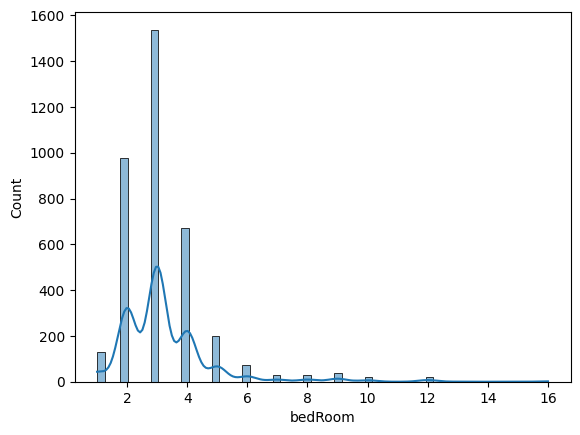

In [94]:
sns.histplot(df['bedRoom'], kde = True)

<Axes: xlabel='bedRoom'>

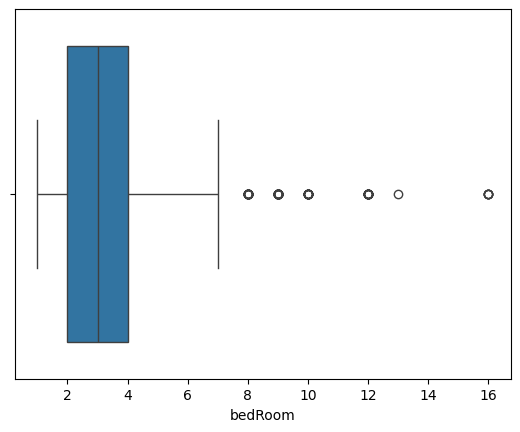

In [95]:
sns.boxplot(x = df['bedRoom'])

In [96]:
df['bedRoom'].describe()

count    3729.000000
mean        3.255833
std         1.607214
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        16.000000
Name: bedRoom, dtype: float64

### bathrooms

In [97]:
df['bathroom'].describe()

count    3729.000000
mean        3.330383
std         1.684549
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        20.000000
Name: bathroom, dtype: float64

<Axes: xlabel='bathroom'>

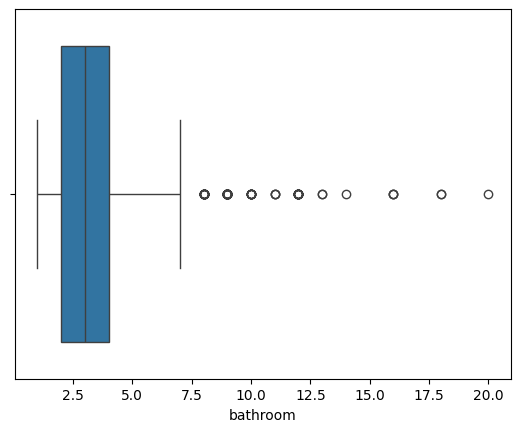

In [98]:
sns.boxplot(x = df['bathroom'])

In [99]:
df[df['bathroom'] > 10]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
223,house,independent,sector 26,10.50,43210.05,2429.99,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,4.0,North-East,relatively new,NaN,300.0,270.0,1,0,1,0,0,0,47.0
339,house,independent,sector 39,7.00,10000.00,7000.00,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,relatively new,NaN,7000.0,NaN,0,0,1,0,0,2,24.0
444,house,independent,sector 46,6.50,27461.04,2366.99,Plot area 263(219.9 sq.m.),12,12,3+,4.0,North-West,relatively new,NaN,2367.0,NaN,0,1,1,0,0,0,17.0
705,house,independent,sector 47,6.09,33665.01,1809.00,Plot area 201(168.06 sq.m.)Built Up area: 180 ...,12,11,3+,4.0,West,relatively old,NaN,180.0,150.0,0,0,1,0,0,2,27.0
877,house,independent,sector 56,11.50,42032.01,2736.01,Plot area 304(254.18 sq.m.),12,13,3+,4.0,West,relatively new,NaN,2736.0,NaN,1,1,1,0,0,0,30.0
930,house,luxury dlf city floors,sector 26,20.00,48889.00,4090.90,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,new,NaN,500.0,NaN,1,0,0,0,0,0,22.0
968,house,independent,sector 27,8.25,45833.08,1800.01,Plot area 210(175.59 sq.m.)Built Up area: 205 ...,12,12,3+,4.0,East,new,NaN,205.0,200.0,1,0,1,0,0,0,21.0
1118,house,independent,sector 57,6.95,38610.90,1800.01,Plot area 192(160.54 sq.m.),12,12,3+,4.0,East,new,NaN,1728.0,NaN,1,0,0,1,0,0,51.0
1225,house,floor wise designer kothi,sector 25,13.00,48147.97,2700.01,Plot area 300(250.84 sq.m.),12,16,3+,4.0,North-East,new,NaN,2700.0,NaN,1,1,1,1,0,2,107.0
1293,house,uppal southend,sector 49,6.75,32327.59,2088.00,Plot area 232(21.55 sq.m.),12,12,3+,NaN,West,relatively old,NaN,232.0,NaN,1,1,1,0,1,0,30.0


### super built up area

In [100]:
df['super_built_up_area'].describe()

count     1912.000000
mean      1920.670094
std        768.544047
min         89.000000
25%       1457.000000
50%       1827.245000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area'>

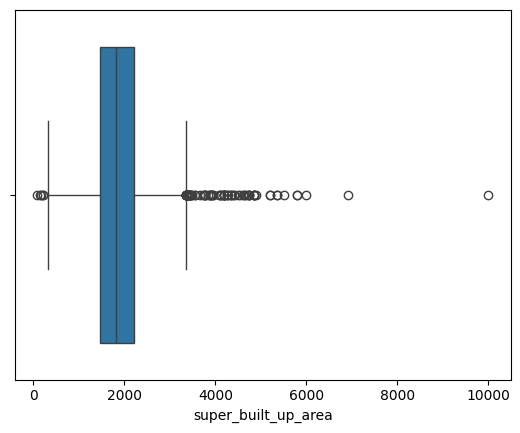

In [101]:
sns.boxplot(x = df['super_built_up_area'])

In [102]:
df[df['super_built_up_area'] > 5000]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
36,flat,krrish provence estate,sector 2,7.50,7500.0,10000.00,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,north-east,relatively new,10000.0,NaN,NaN,1,0,1,0,1,1,24.0
92,flat,paras quartier,sector 2,7.50,14018.0,5350.26,Super Built up area 5350(497.03 sq.m.),4,4,3+,20.0,north-east,new,5350.0,NaN,NaN,1,0,1,0,1,0,24.0
848,flat,krrish provence estate,sector 2,5.25,9051.0,5800.46,Super Built up area 5800(538.84 sq.m.),4,5,3+,2.0,north-east,new,5800.0,NaN,NaN,1,1,1,0,0,1,24.0
1119,flat,raheja vedas,sector 108,2.15,4134.0,5200.77,Super Built up area 5200(483.1 sq.m.)Built Up ...,3,4,3+,12.0,east,relatively new,5200.0,4600.0,4000.0,0,1,0,0,0,1,NaN
1394,flat,beverley park 1,sector 43,8.44,16230.0,5200.25,Super Built up area 5200(483.1 sq.m.)Built Up ...,4,5,3,9.0,north-east,relatively old,5200.0,5000.0,4900.0,1,0,0,0,0,2,91.0
1700,flat,bestech park view grand spa,sector 81,4.70,6786.0,6926.02,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,north,relatively new,6926.0,NaN,NaN,1,0,0,0,0,0,127.0
1942,flat,.,sector 2,7.00,11000.0,6363.64,Super Built up area 6000(557.42 sq.m.),4,4,3+,6.0,south-west,relatively new,6000.0,NaN,NaN,1,0,0,0,0,1,38.0
3259,flat,krrish provence estate,sector 2,5.50,9482.0,5800.46,Super Built up area 5800(538.84 sq.m.),4,5,3+,11.0,east,new,5800.0,NaN,NaN,1,1,1,0,0,1,126.0
3505,flat,paras quartier,sector 2,5.90,11028.0,5350.02,Super Built up area 5350(497.03 sq.m.),4,4,3+,19.0,east,new,5350.0,NaN,NaN,1,1,1,1,0,0,147.0
3713,flat,pioneer araya,sector 62,10.75,19500.0,5512.82,Super Built up area 5514(512.27 sq.m.),5,7,3,10.0,north-east,relatively new,5514.0,NaN,NaN,1,0,0,0,0,0,125.0


<Axes: xlabel='super_built_up_area', ylabel='Count'>

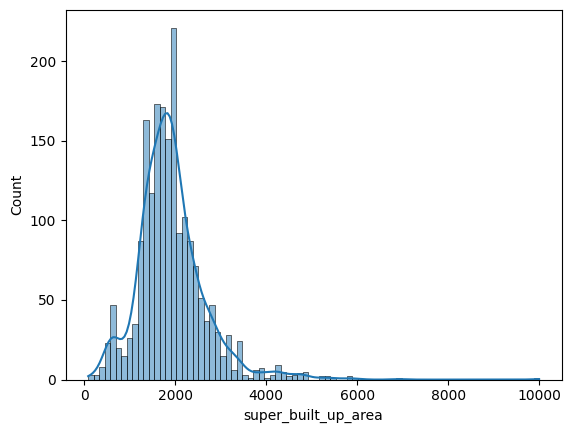

In [103]:
sns.histplot(df['super_built_up_area'], kde = True)

### built up area

<Axes: xlabel='built_up_area', ylabel='Count'>

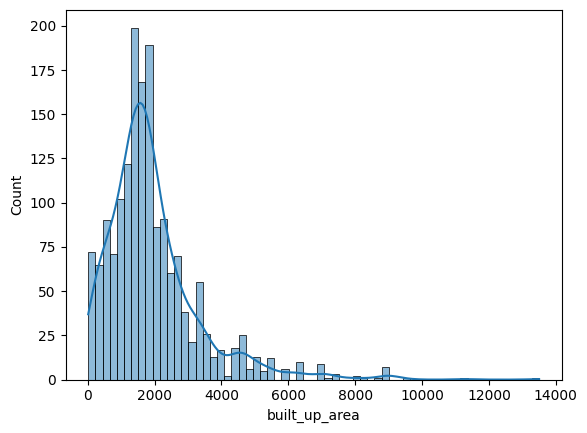

In [105]:
sns.histplot(df['built_up_area'], kde = True)

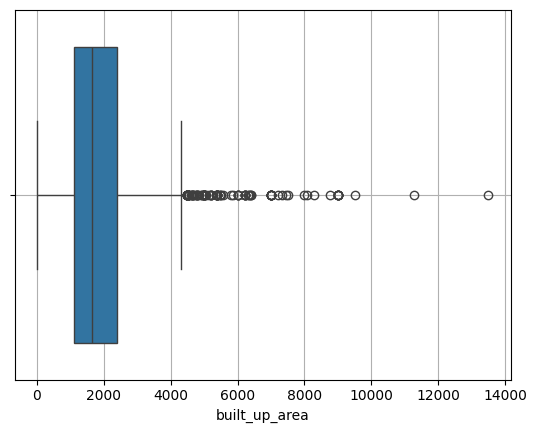

In [108]:
sns.boxplot(x= df['built_up_area'])
plt.grid()

In [ ]:
df[df['built_up_area'] > 8500][['price_in_cr', 'price_per_sqft', 'area', 'built_up_area', 'bedRoom', 'bathroom', 'luxury_score']]

#1776, --> seem problamatic, removing it 

,price_in_cr,price_per_sqft,area,built_up_area,bedRoom,bathroom,luxury_score
274,27.50,24366.00,11286.22,11286.0,6,7,28.0
1568,19.50,22222.00,8775.09,8775.0,5,6,97.0
1754,17.00,35109.02,4842.06,9000.0,5,8,68.0
1776,0.85,630.00,13492.06,13500.0,3,3,NaN
1784,9.00,38022.01,2367.05,9000.0,12,12,62.0
1833,6.00,14492.00,4140.22,9000.0,9,9,9.0
1881,23.00,25556.01,8999.84,9000.0,4,4,116.0
2656,10.00,37037.04,2700.00,9500.0,5,5,21.0
2878,11.50,17692.00,6500.11,9000.0,7,8,20.0
3530,31.50,35000.00,9000.00,9000.0,7,9,63.0


In [112]:
df.drop(index = 1776, inplace = True)

In [118]:
df[df['built_up_area'] < 50]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
467,house,rk excelo,sector 8,0.60,13333.33,450.00,Plot area 50(4.65 sq.m.)Built Up area: 30 sq.f...,5,3,2,3.0,North,relatively old,NaN,30.0,15.0,0,0,0,0,1,1,NaN
569,house,independent,sector 47,0.08,2525.00,316.83,Plot area 33(27.59 sq.m.),1,1,0,1.0,NaN,relatively new,NaN,33.0,NaN,0,0,0,0,0,1,NaN


In [117]:
df.loc[2272, 'built_up_area'] = 3149.94

### carpet area

In [119]:
df['carpet_area'].describe()

count     1922.000000
mean      1427.336660
std       1040.690947
min         15.000000
25%        830.000000
50%       1290.000000
75%       1760.000000
max      18122.000000
Name: carpet_area, dtype: float64

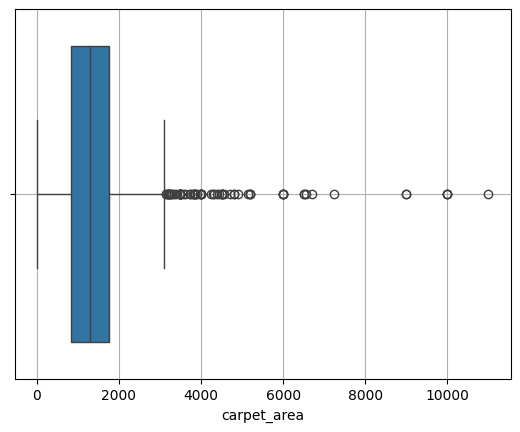

In [126]:
sns.boxplot(x = df['carpet_area'])
plt.grid()

In [125]:
df[df['carpet_area'] > 8000]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
1831,flat,the penthouses at the hibiscus,sector 50,8.00,8888.00,9000.9,Carpet area: 9000 (836.13 sq.m.),4,3,3,7.0,south-east,relatively old,NaN,NaN,9000.0,1,0,0,0,0,1,36.0
2576,flat,m3m golfestate,sector 65,13.20,12000.00,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,north,relatively old,NaN,NaN,11000.0,1,0,0,0,0,1,48.0
2656,house,independent,sector 25,10.00,37037.04,2700.0,Plot area 2700(250.84 sq.m.)Built Up area: 950...,5,5,3+,3.0,East,relatively old,NaN,9500.0,9000.0,1,0,1,0,0,2,21.0
2945,house,independent,sector 26,18.25,18250.00,10000.0,Plot area 550(51.1 sq.m.)Carpet area: 10000 sq...,7,9,3+,4.0,East,relatively new,NaN,NaN,10000.0,1,1,1,1,0,0,58.0
3470,house,independent,sector 25,8.00,8000.00,10000.0,Carpet area: 10000 (929.03 sq.m.),3,9,2,3.0,NaN,new,NaN,NaN,10000.0,0,0,0,0,0,1,NaN
3589,flat,the penthouses at the hibiscus,sector 50,8.50,8500.00,10000.0,Carpet area: 10000 (929.03 sq.m.),4,4,3,9.0,south-east,relatively old,NaN,NaN,10000.0,1,0,0,0,0,1,36.0


In [124]:
df.loc[3030, 'carpet_area'] = 1812.0

### luxury score

<Axes: xlabel='luxury_score', ylabel='Count'>

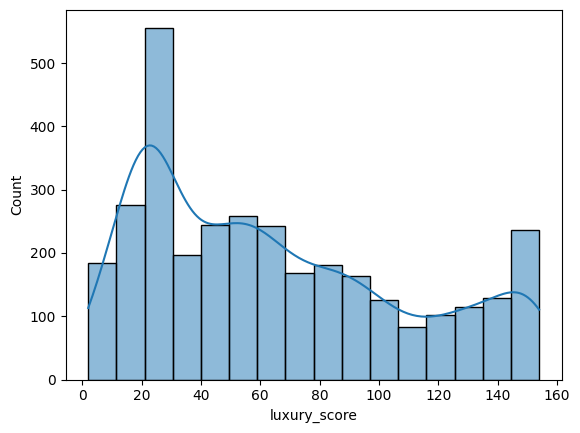

In [127]:
sns.histplot(df['luxury_score'], kde = True)

<Axes: ylabel='luxury_score'>

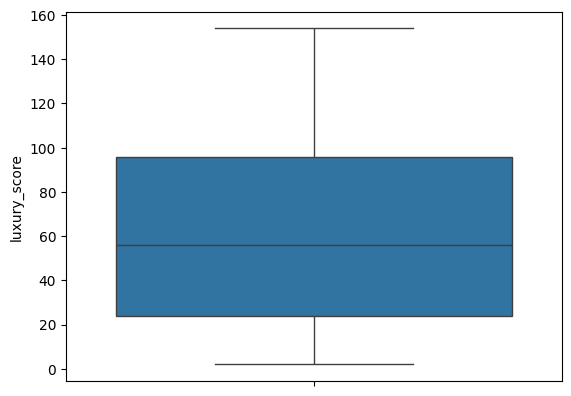

In [128]:
sns.boxplot(df['luxury_score'])

In [149]:
# updating price per sqft since we have made changed to area column

df['price_per_sqft'] = ((df['price_in_cr']*10000000)/(df['area'])).round(2)

In [151]:
df['price_per_sqft'].describe()

count     3728.000000
mean     11451.025091
std       7415.880430
min        544.000000
25%       6778.730000
50%       8928.000000
75%      13356.222500
max      49500.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft'>

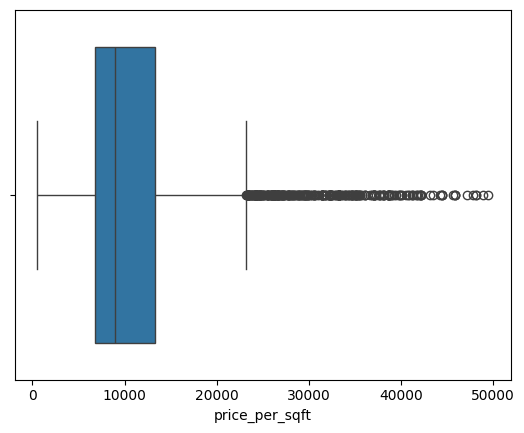

In [145]:
sns.boxplot(x = df['price_per_sqft'])

<Axes: xlabel='price_per_sqft', ylabel='Count'>

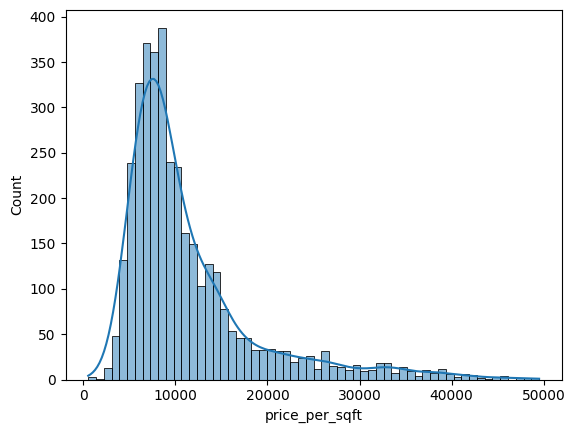

In [146]:
sns.histplot(df['price_per_sqft'], kde = True)

- calculate area vs number of bedroom for flats with less than 20000 price_per_sqft(normal properties)

In [ ]:
temp_df = df[df['price_per_sqft'] <= 20000]
(temp_df['area']/df['bedRoom']).quantile(0.05)      # 5 percentile value of area/bedroom 

np.float64(262.3605)

In [187]:
temp_df = df[(df['area']/df['bedRoom']< 257)]

In [188]:
temp_df['area_bedroom_ratio'] = (temp_df['area']/temp_df['bedRoom'])

In [189]:
temp_df['area_bedroom_ratio'] = temp_df['area_bedroom_ratio'].round(2)

In [190]:
temp_df.sort_values('area_bedroom_ratio', ascending=False).tail(10)

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,area_bedroom_ratio
3729,house,rattan vihar rajendra park,sector 104,0.85,14165.96,600.03,Plot area 600(55.74 sq.m.),5,5,3+,4.0,NaN,new,NaN,600.0,NaN,0,0,0,0,0,1,NaN,120.01
2541,house,surendra homes dayanand colony,sector 6,0.75,15625.00,480.00,Built Up area: 480 (44.59 sq.m.),4,4,2,1.0,NaN,undefined,NaN,480.0,NaN,0,0,0,0,0,1,NaN,120.00
2699,house,independent,sector 2,0.98,9073.99,1080.01,Carpet area: 120 (100.34 sq.m.),9,4,3,1.0,South,undefined,NaN,NaN,120.0,0,0,0,0,0,1,NaN,120.00
788,house,independent,sector 6,0.75,10518.05,713.06,Plot area 713(66.24 sq.m.),6,4,1,3.0,NaN,relatively old,NaN,713.0,NaN,0,0,0,0,0,1,42.0,118.84
441,house,independent,sector 89,0.32,5664.02,564.97,Built Up area: 565 (52.49 sq.m.),5,1,0,1.0,NaN,undefined,NaN,565.0,NaN,0,0,0,0,0,1,NaN,112.99
1336,house,housing board colony,sector 28,2.10,23333.07,900.01,Plot area 100(83.61 sq.m.),8,8,3+,4.0,South-East,relatively old,NaN,900.0,NaN,0,0,0,0,1,0,24.0,112.50
3421,house,independent,sector 7,0.27,12000.00,225.00,Plot area 225(20.9 sq.m.),2,2,1,2.0,North-East,relatively old,NaN,225.0,NaN,0,0,0,0,0,1,5.0,112.50
3281,house,independent,sector 3,0.50,9258.92,540.02,Plot area 540(50.17 sq.m.),5,3,2,3.0,West,old,NaN,540.0,NaN,0,0,0,0,0,1,NaN,108.00
25,house,independent,sector 47,0.95,8920.02,1065.02,Plot area 1065(98.94 sq.m.),10,10,3+,3.0,NaN,new,NaN,1065.0,NaN,0,0,0,0,0,1,NaN,106.50
126,house,ganpati heights apartment,sector 12,1.25,12077.29,1035.00,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,old,NaN,115.0,NaN,0,0,0,0,1,1,4.0,103.50


In [191]:
temp_df.shape

(208, 24)

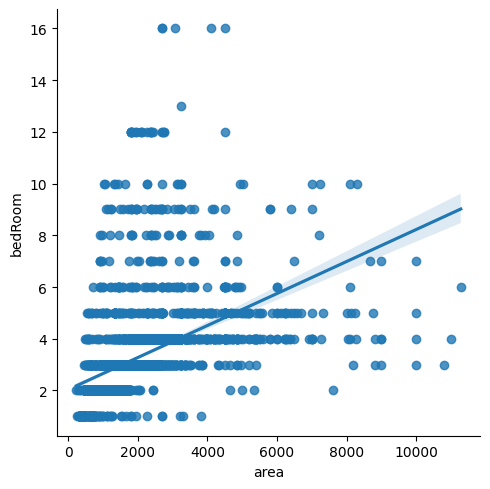

In [192]:
sns.lmplot(data = df, x = 'area', y = 'bedRoom')

In [ ]:
# remove the ones whose area vs bedroom is very poor < 100

temp_df_remove = temp_df[temp_df['area_bedroom_ratio'] < 100]
temp_df_remove.index

Index([], dtype='int64')

In [194]:
df.drop(index = temp_df_remove.index, inplace = True)

In [195]:
temp_df = temp_df[temp_df['area_bedroom_ratio'] >= 100]

- rows where the area vs bedroom ratio is less than 250 and number of bedrooms are more than 4, chances are that they are multi floor houses

In [200]:
temp_df[temp_df['area_bedroom_ratio'] < 250]['property_type'].value_counts()

property_type
house    138
flat      52
Name: count, dtype: int64

In [202]:
df['area_bedroom_ratio'] = (df['area'] / df['bedRoom']).round(2)

In [204]:
outlier_df = df[(df['area_bedroom_ratio'] < 250) & (df['bedRoom'] > 4) & (df['property_type'] == 'house')]

In [205]:
outlier_df['bedRoom'] = round(outlier_df['bedRoom'] / outlier_df['floorNum'])

In [208]:
df.update(outlier_df)

In [ ]:
# update the area bedoom ratio valuses
df['area_bedroom_ratio'] = df['area']/df['bedRoom']

In [219]:
temp_df_remove = df[(df['area_bedroom_ratio'] < 250) & (df['bedRoom'] > 4)]

In [221]:
df.drop(index = temp_df.index, inplace=True)

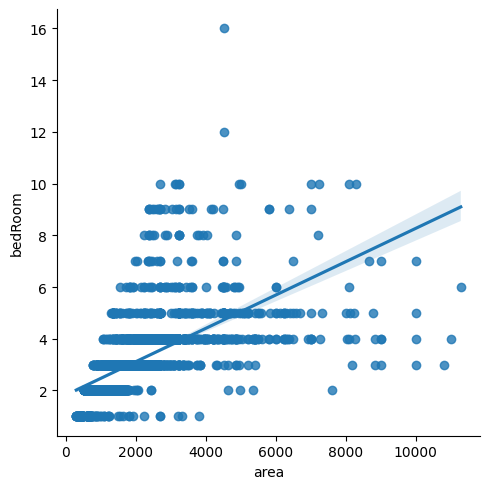

In [222]:
sns.lmplot(data = df, x = 'area', y = 'bedRoom')

- lmplot looks slightly better after making the bedroom transformation

In [223]:
# saving the file
df.to_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_v3.csv', index = False)